# Notebook 03b — Variable Objetivo: Infección Postoperatoria
## TFG — Predicción de Complicaciones Postquirúrgicas 

**Objetivo**: construir la variable binaria `infeccion_postop` (0 = no infección, 1 = infección) a partir de los diagnósticos CIE-10 del archivo `016_HOSPITALIZACION_DIAGNOSTICO_PRINCIPAL.csv`.

**Fuente principal**: `post/016_HOSPITALIZACION_DIAGNOSTICO_PRINCIPAL.csv`  
**Población de referencia**: `static/000_POBLACION_DIANA.csv` (lista completa de pacientes)  
**Salida**: `results/y_infeccion_postop.csv`

---

### Criterio de inclusión como caso positivo

Un paciente se clasifica como **infección postoperatoria (y=1)** si tiene registrado en el alta hospitalaria **al menos un diagnóstico CIE-10** que pertenezca a alguna de las siguientes categorías clínicas:

| Categoría | Descripción | Prefijos CIE-10 |
|---|---|---|
| `sepsis` | Sepsis / septicemia | A40*, A41* |
| `resp` | Infección respiratoria (neumonía, bronquitis aguda, EPOC infectado) | J1*, J2*, J4* |
| `ssi` | Infección de herida / sitio quirúrgico | T81.4*, T81.8*, T81.89* |
| `itu` | Infección del tracto urinario | N39.0* |
| `cateter` | Infección relacionada con catéter / dispositivo | T80.2*, T82.7*, T85.7*, Z51.11 |
| `other` | Otras infecciones con relevancia clínica | L03*, K61*, K94.1*, J36*, N41*, K65*, M00*, M86*, G00*, G06* |

Se aplica orden de prioridad: `cateter > sepsis > ssi > itu > resp > other`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DIV     = PROJECT_ROOT / "data" / "data_divided"
RESULTS = PROJECT_ROOT / "results"
RESULTS.mkdir(exist_ok=True)

print(f"Proyecto : {PROJECT_ROOT}")
print(f"Dividido : {DIV}")
print(f"Resultados: {RESULTS}")


Proyecto : /Users/ikerarias/Desktop/TFG
Dividido : /Users/ikerarias/Desktop/TFG/data/data_divided
Resultados: /Users/ikerarias/Desktop/TFG/results


## 1. Población de referencia

Cargamos `000_POBLACION_DIANA.csv` para obtener la lista completa de pacientes del estudio. Cada paciente tendrá exactamente una fila en la variable objetivo final.


In [2]:
df_pop = pd.read_csv(DIV / "static" / "000_POBLACION_DIANA.csv",
                     sep=";", engine="python", on_bad_lines="skip")
df_pop.columns = df_pop.columns.str.strip()
df_pop["id_paciente"] = df_pop["Id_Paciente"].astype(str).str.strip()
df_pop = df_pop.drop_duplicates(subset="id_paciente")[["id_paciente"]]

print(f"Población total: {len(df_pop):,} pacientes únicos")
df_pop.head(5)


Población total: 13,662 pacientes únicos


,id_paciente
0,17598
1,84611
2,39314
3,60484
4,86923


## 2. Carga del archivo de diagnósticos al alta (016)

`016_HOSPITALIZACION_DIAGNOSTICO_PRINCIPAL.csv` contiene los diagnósticos CIE-10 registrados al alta de cada episodio de hospitalización. Un paciente puede tener múltiples diagnósticos y múltiples episodios.


In [3]:
df_dx = pd.read_csv(DIV / "post" / "016_HOSPITALIZACION_DIAGNOSTICO_PRINCIPAL.csv",
                    engine="python", on_bad_lines="skip")
df_dx.columns = df_dx.columns.str.strip()
df_dx["id_paciente"] = df_dx["id_paciente"].astype(str).str.strip()

# Normalizar código CIE-10: mayúsculas, sin espacios
df_dx["cod"] = df_dx["cod Diagnóstico CIE10"].astype(str).str.strip().str.upper()

print(f"Diagnósticos al alta: {df_dx.shape[0]:,} filas | {df_dx['id_paciente'].nunique():,} pacientes únicos")
print(f"\nColumnas: {df_dx.columns.tolist()}")
print(f"\nEjemplo de códigos CIE-10 más frecuentes:")
print(df_dx["cod"].value_counts().head(20).to_string())


Diagnósticos al alta: 4,024 filas | 2,800 pacientes únicos

Columnas: ['id_paciente', 'id_episodio', 'fecha_evento', 'cod Diagnóstico CIE10', 'Diagnóstico CIE10', 'Órden diagnóstico', 'Fecha (alta)', 'Servicio HOSP (ingreso)', 'Circunstancia alta', 'cod']

Ejemplo de códigos CIE-10 más frecuentes:
cod
H269       936
N390        63
Z5111       63
C679        57
A419        55
C61         49
I509        47
J189        45
J441        40
T814XXA     38
J22         36
J988        30
K4090       29
J1289       28
N201        27
N200        23
J440        23
Z466        22
H3322       22
N179        19


## 3. Taxonomía CIE-10 de infecciones postoperatorias

Definimos las **expresiones regulares** para cada categoría clínica de infección. Se evalúan en orden de prioridad: si un paciente cumple múltiples criterios, se le asigna la categoría de mayor prioridad.


In [4]:
# Taxonomía CIE-10 por categoría (orden de prioridad descendente)
# Las claves son las categorías; los valores, expresiones regulares sobre el código CIE-10
INFECCION_REGEX = {
    "cateter": r"^(T802|T827|T857|Z5111)",        # infección por catéter/dispositivo
    "sepsis":  r"^(A40|A41)",                      # sepsis / septicemia
    "ssi":     r"^(T814|T818|T819)",               # infección sitio quirúrgico (wound infection)
    "itu":     r"^N390",                            # infección tracto urinario
    "resp":    r"^(J1[0-9]|J2[0-9]|J4[0-9])",     # infecciones respiratorias (neumonía, EPOC inf.)
    "other":   r"^(L03|K61|K941|J36|N41|K65|M00|M86|G00|G06)",  # otras infecciones clínicas
}

# Etiquetar cada fila del dataframe de diagnósticos
def clasificar_codigo(cod):
    for categoria, patron in INFECCION_REGEX.items():
        if pd.notna(cod) and pd.Series([cod]).str.match(patron).iloc[0]:
            return categoria
    return None

df_dx["categoria"] = df_dx["cod"].apply(clasificar_codigo)

print("Diagnósticos con código de infección encontrado:")
print(df_dx["categoria"].value_counts(dropna=False).to_string())

# Pacientes con al menos un diagnóstico de infección
df_inf = df_dx[df_dx["categoria"].notna()].copy()
print(f"\nRegistros de infección: {len(df_inf):,}")
print(f"Pacientes únicos con infección: {df_inf['id_paciente'].nunique():,}")


Diagnósticos con código de infección encontrado:
categoria
NaN        3473
resp        250
sepsis       77
cateter      74
itu          63
ssi          48
other        39

Registros de infección: 551
Pacientes únicos con infección: 413


## 4. Asignación de categoría por paciente

Por cada paciente, nos quedamos con la **categoría de mayor prioridad** entre todos sus diagnósticos de infección. El orden de prioridad ya está codificado en el diccionario `INFECCION_REGEX` (iteración en orden).


In [5]:
# Orden de prioridad para resolver conflictos (menor índice = mayor prioridad)
PRIORIDAD = {cat: i for i, cat in enumerate(INFECCION_REGEX.keys())}

# Por paciente: seleccionar la categoría de mayor prioridad (menor índice)
df_inf["prioridad"] = df_inf["categoria"].map(PRIORIDAD)
df_paciente_cat = (
    df_inf.sort_values("prioridad")
    .groupby("id_paciente")["categoria"]
    .first()
    .reset_index()
    .rename(columns={"categoria": "categoria_infeccion"})
)

print(f"Pacientes con infección clasificados: {len(df_paciente_cat):,}")
print("\nDistribución de categorías:")
print(df_paciente_cat["categoria_infeccion"].value_counts().to_string())


Pacientes con infección clasificados: 413

Distribución de categorías:
categoria_infeccion
resp       193
sepsis      67
itu         53
ssi         40
cateter     35
other       25


## 5. Construcción de la variable objetivo final

Unimos con la población completa: los pacientes **sin** ningún diagnóstico de infección reciben `infeccion_postop=0` y `categoria_infeccion="ninguna"`.


In [6]:
# Left join: todos los pacientes de la población + los que tienen infección
y = df_pop.merge(df_paciente_cat, on="id_paciente", how="left")
y["infeccion_postop"] = y["categoria_infeccion"].notna().astype(int)
y["categoria_infeccion"] = y["categoria_infeccion"].fillna("ninguna")

print("=== Variable objetivo final ===")
print(f"Total pacientes : {len(y):,}")
print(f"Positivos (y=1) : {y['infeccion_postop'].sum():,} ({y['infeccion_postop'].mean()*100:.2f}%)")
print(f"Negativos (y=0) : {(y['infeccion_postop']==0).sum():,}")
print(f"Ratio neg/pos   : {(y['infeccion_postop']==0).sum() / y['infeccion_postop'].sum():.1f}:1")
print(f"\nCategor\u00edas de infecci\u00f3n:")
print(y["categoria_infeccion"].value_counts().to_string())

y.head(8)


=== Variable objetivo final ===
Total pacientes : 13,662
Positivos (y=1) : 413 (3.02%)
Negativos (y=0) : 13,249
Ratio neg/pos   : 32.1:1

Categorías de infección:
categoria_infeccion
ninguna    13249
resp         193
sepsis        67
itu           53
ssi           40
cateter       35
other         25


,id_paciente,categoria_infeccion,infeccion_postop
0,17598,ninguna,0
1,84611,ninguna,0
2,39314,ninguna,0
3,60484,ninguna,0
4,86923,ninguna,0
5,86855,ninguna,0
6,3870,ninguna,0
7,89721,ninguna,0


## 6. Visualización del desbalanceo


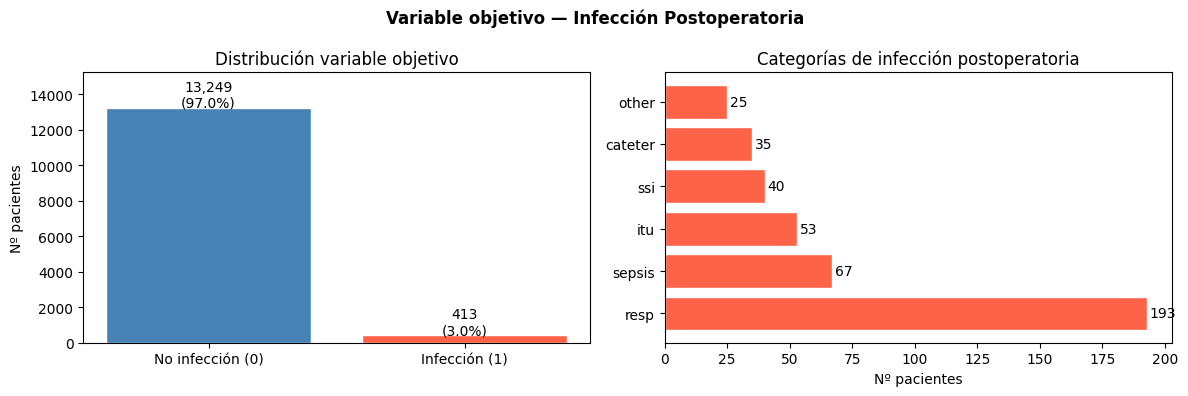

Gráfica guardada → results/distribucion_y_infeccion.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico 1: distribución binaria
counts = y["infeccion_postop"].value_counts().sort_index()
axes[0].bar(["No infección (0)", "Infección (1)"], counts.values,
            color=["steelblue", "tomato"], edgecolor="white")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, f"{v:,}\n({v/len(y)*100:.1f}%)", ha="center", fontsize=10)
axes[0].set_title("Distribución variable objetivo")
axes[0].set_ylabel("Nº pacientes")
axes[0].set_ylim(0, counts.max() * 1.15)

# Gráfico 2: categorías de infección (solo positivos)
cat_counts = y[y["infeccion_postop"] == 1]["categoria_infeccion"].value_counts()
axes[1].barh(cat_counts.index, cat_counts.values, color="tomato", edgecolor="white")
for i, (idx, v) in enumerate(cat_counts.items()):
    axes[1].text(v + 1, i, str(v), va="center", fontsize=10)
axes[1].set_title("Categorías de infección postoperatoria")
axes[1].set_xlabel("Nº pacientes")

plt.suptitle("Variable objetivo — Infección Postoperatoria", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(RESULTS / "distribucion_y_infeccion.png", dpi=150)
plt.show()
print("Gráfica guardada → results/distribucion_y_infeccion.png")


## 7. Exportación

Guardamos `y_infeccion_postop.csv` en la carpeta `results/`. Este archivo es la entrada de `ntb_04_construccion_features_infeccion.ipynb`.


In [8]:
out_path = RESULTS / "y_infeccion_postop.csv"
y[["id_paciente", "infeccion_postop", "categoria_infeccion"]].to_csv(out_path, index=False)

print(f"Exportado → {out_path}")
print(f"Shape: {y.shape}")
print(f"\nPrimeras filas:")
print(y.head(5).to_string(index=False))


Exportado → /Users/ikerarias/Desktop/TFG/results/y_infeccion_postop.csv
Shape: (13662, 3)

Primeras filas:
id_paciente categoria_infeccion  infeccion_postop
      17598             ninguna                 0
      84611             ninguna                 0
      39314             ninguna                 0
      60484             ninguna                 0
      86923             ninguna                 0
